# Time-Series Autoencoder in PyTorch

In [ ]:
# Setup
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score

# Reproducibility
SEED = 999
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [3]:
#Data generation

# Define the x range
x_range = np.linspace(-8 * np.pi, 8 * np.pi, 1000)

# Define normal and weird frequencies
normal_frequencies = np.linspace(-2, 2, 1000)
weird_frequencies = np.hstack((np.linspace(-10, -5, 500), np.linspace(5, 10, 500)))

# Define normal and weird amplitudes
normal_amplitudes = np.linspace(-2, 2, 1000)
weird_amplitudes = np.hstack((np.linspace(-5, -2, 500), np.linspace(2, 5, 500)))

def build_signals(num=1000, num_components=5, freqs_pool=None, amps_pool=None, rng=None):
    signals = []
    for _ in range(num):
        freqs = rng.choice(freqs_pool, num_components, replace=True)
        amps = rng.choice(amps_pool, num_components, replace=True)
        sigs = [amps[i] * np.sin(freqs[i] * x_range) for i in range(num_components)]
        signals.append(np.sum(sigs, axis=0))
    return np.asarray(signals, dtype=np.float32)

normal_signals = build_signals(num=1000, num_components=5, freqs_pool=normal_frequencies, amps_pool=normal_amplitudes, rng=rng)
weird_signals  = build_signals(num=1000, num_components=5, freqs_pool=weird_frequencies,  amps_pool=weird_amplitudes, rng=rng)

normal_signals.shape, weird_signals.shape


((1000, 1000), (1000, 1000))

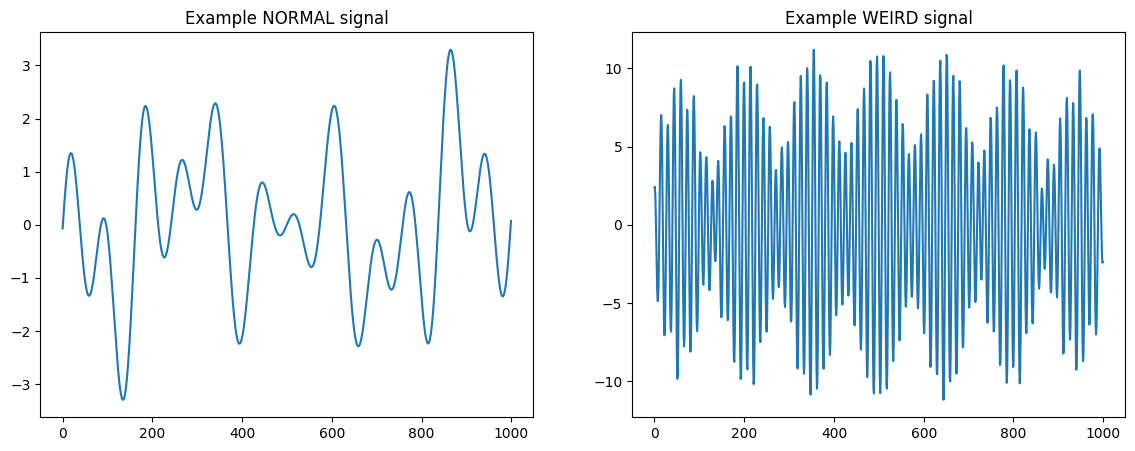

In [4]:

#Quick look at samples
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
idx = np.random.randint(0, len(normal_signals))
plt.plot(normal_signals[idx])
plt.title("Example NORMAL signal")

plt.subplot(1, 2, 2)
idx = np.random.randint(0, len(weird_signals))
plt.plot(weird_signals[idx])
plt.title("Example WEIRD signal")
plt.show()


In [ ]:
# Normalize signals (zero-mean, unit-std across the training set)
# We'll compute mean/std from normal_signals only (unsupervised learning assumption).
mean = normal_signals.mean()
std  = normal_signals.std() + 1e-8

normal_norm = (normal_signals - mean) / std
weird_norm  = (weird_signals  - mean) / std

# Torch tensors
X_normal = torch.from_numpy(normal_norm)
X_weird  = torch.from_numpy(weird_norm)

# Autoencoder will reconstruct the input -> targets are same as inputs
dataset = TensorDataset(X_normal, X_normal)

# Train/Val split
n_total = len(dataset)
n_val = int(0.2 * n_total)
n_train = n_total - n_val
train_set, val_set = random_split(dataset, [n_train, n_val], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_set, batch_size=64, shuffle=True, drop_last=False)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False, drop_last=False)

# Test data (for anomaly scoring): we'll use normal + weird
X_test = torch.cat([X_normal, X_weird], dim=0)
y_test = torch.cat([torch.zeros(len(X_normal)), torch.ones(len(X_weird))], dim=0)  # 0=normal, 1=weird
X_test.shape, y_test.shape


(torch.Size([2000, 1000]), torch.Size([2000]))

In [ ]:
# MLP Autoencoder
#(Input:1000-d vector)

class MLPAutoencoder(nn.Module):
    def __init__(self, input_dim=1000, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim),
        )
    def forward(self, x):
        # x: [B, 1000]
        z = self.encoder(x)
        out = self.decoder(z)
        return out, z

model = MLPAutoencoder(input_dim=1000, latent_dim=32).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
model


MLPAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=1000, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=1000, bias=True)
  )
)

In [7]:
# Training loop with simple early stopping

def evaluate(loader):
    model.eval()
    total_loss = 0.0
    count = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            preds, _ = model(xb)
            loss = criterion(preds, yb)
            total_loss += loss.item() * xb.size(0)
            count += xb.size(0)
    return total_loss / max(count, 1)

best_val = float("inf")
patience = 10
pat = 0
EPOCHS = 100

train_history = []
val_history = []

for epoch in range(1, EPOCHS+1):
    model.train()
    running = 0.0
    seen = 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        preds, _ = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        running += loss.item() * xb.size(0)
        seen += xb.size(0)

    train_loss = running / max(seen, 1)
    val_loss = evaluate(val_loader)

    train_history.append(train_loss)
    val_history.append(val_loss)

    # Early stopping
    if val_loss < best_val - 1e-6:
        best_val = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        pat = 0
    else:
        pat += 1
        if pat >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d}: train={train_loss:.6f}  val={val_loss:.6f}")

# Load best weights
model.load_state_dict(best_state)

Epoch 001: train=0.917793  val=0.762138
Epoch 005: train=0.063827  val=0.052561
Epoch 010: train=0.018524  val=0.024974
Epoch 015: train=0.014785  val=0.020752
Epoch 020: train=0.011610  val=0.015641
Epoch 025: train=0.007519  val=0.010351
Epoch 030: train=0.006322  val=0.009516
Epoch 035: train=0.006545  val=0.009704
Epoch 040: train=0.006533  val=0.010667
Early stopping at epoch 43


<All keys matched successfully>

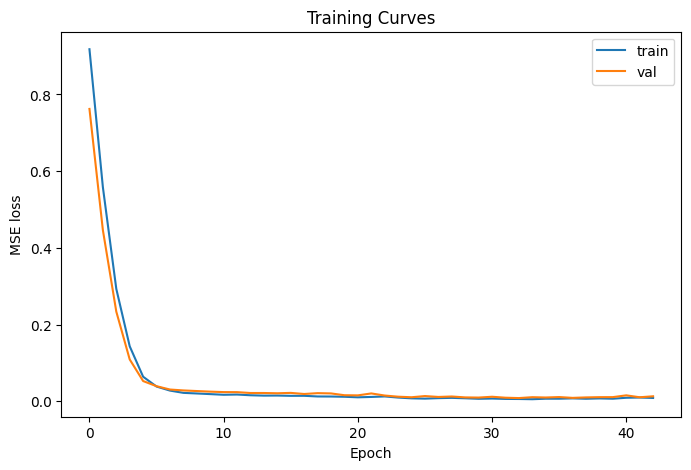

In [8]:
# Plot training curves
plt.figure(figsize=(8,5))
plt.plot(train_history, label="train")
plt.plot(val_history, label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training Curves")
plt.legend()
plt.show()

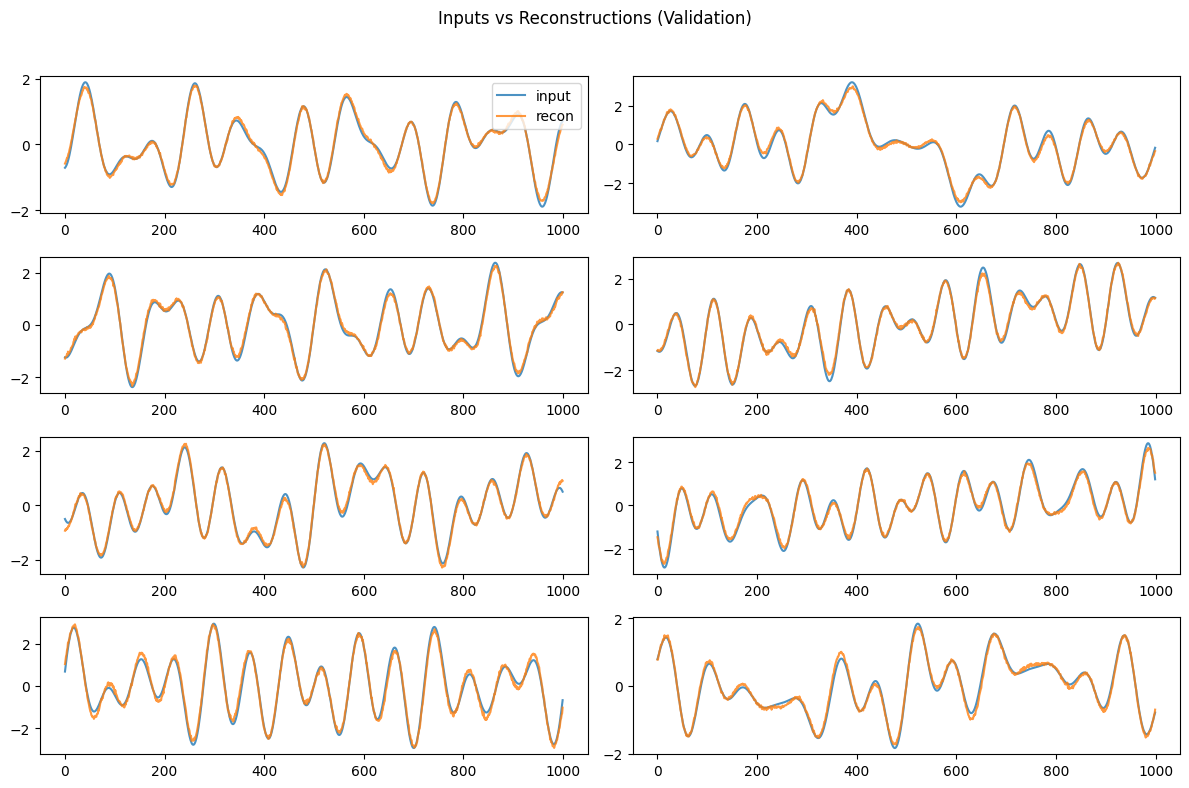

In [9]:

# Reconstructions on validation samples
model.eval()
with torch.no_grad():
    xb, yb = next(iter(val_loader))
    xb = xb.to(device)
    recons, z = model(xb)
    xb_np = xb[:8].cpu().numpy()
    re_np  = recons[:8].cpu().numpy()

plt.figure(figsize=(12, 8))
for i in range(8):
    plt.subplot(4, 2, i+1)
    plt.plot(xb_np[i], alpha=0.8, label="input")
    plt.plot(re_np[i], alpha=0.8, label="recon")
    if i == 0:
        plt.legend()
plt.suptitle("Inputs vs Reconstructions (Validation)")
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()
